In [18]:
# ── CELL 1 — Import Libraries ──────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully! ✅")

TensorFlow version: 2.19.0
All libraries imported successfully! ✅


In [19]:
# ── CELL 2 — Load & Prepare MNIST Dataset ──────────────────
# Load MNIST dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"Training samples  : {x_train.shape[0]}")
print(f"Testing samples   : {x_test.shape[0]}")
print(f"Image shape       : {x_train.shape[1:]}")
print(f"Labels (0-9)      : {np.unique(y_train)}")

Training samples  : 60000
Testing samples   : 10000
Image shape       : (28, 28)
Labels (0-9)      : [0 1 2 3 4 5 6 7 8 9]


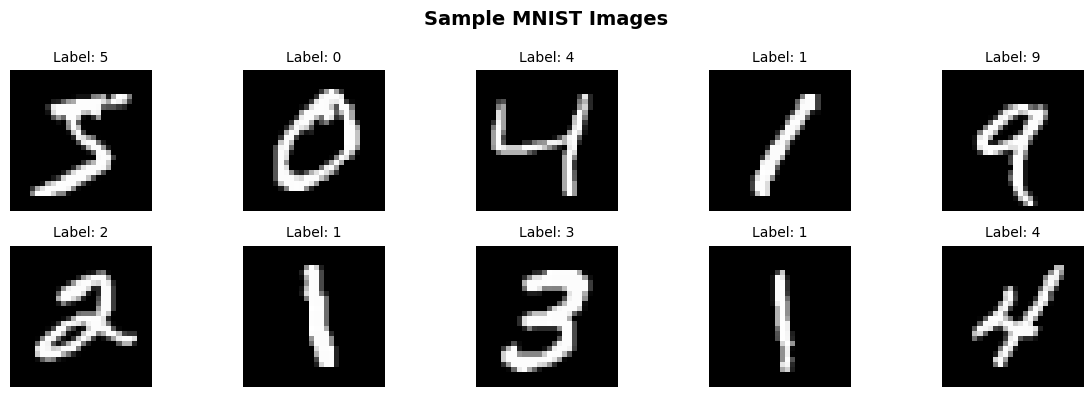

In [20]:
# ── CELL 3 — Visualize Sample Images ───────────────────────
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}", fontsize=10)
    plt.axis('off')
plt.suptitle("Sample MNIST Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# ── CELL 4 — Preprocess Data ───────────────────────────────
# Normalize pixel values to range 0 → 1
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# Add channel dimension → (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test  = np.expand_dims(x_test,  axis=-1)

print(f"x_train shape after preprocessing: {x_train.shape}")
print(f"x_test  shape after preprocessing: {x_test.shape}")
print("Data preprocessing complete! ✅")

x_train shape after preprocessing: (60000, 28, 28, 1)
x_test  shape after preprocessing: (10000, 28, 28, 1)
Data preprocessing complete! ✅


In [22]:
# ── CELL 5 — Build CNN Model ────────────────────────────────
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    # Block 1
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Block 2
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Block 3
    tf.keras.layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),

    # Fully Connected
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# ── CELL 6 — Train the Model ────────────────────────────────
print("\nTraining CNN model...")
history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)
print("\nModel training complete! ✅")


Training CNN model...
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 47s 96ms/step - accuracy: 0.8247 - loss: 0.5460 - val_accuracy: 0.9863 - val_loss: 0.0426
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - accuracy: 0.9776 - loss: 0.0780 - val_accuracy: 0.9890 - val_loss: 0.0299
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 93ms/step - accuracy: 0.9844 - loss: 0.0510 - val_accuracy: 0.9920 - val_loss: 0.0248
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - accuracy: 0.9886 - loss: 0.0411 - val_accuracy: 0.9913 - val_loss: 0.0257
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 93ms/step - accuracy: 0.9898 - loss: 0.0333 - val_accuracy: 0.9924 - val_loss: 0.0222
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 95ms/step - accuracy: 0.9921 - loss: 0.0275 - val_accuracy: 0.9936 - val_loss: 0.0202
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - accuracy: 0.9931 - loss: 0.0243 - val_accuracy: 0.9917 - val_loss: 0.0265
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 95ms/step - accuracy: 0

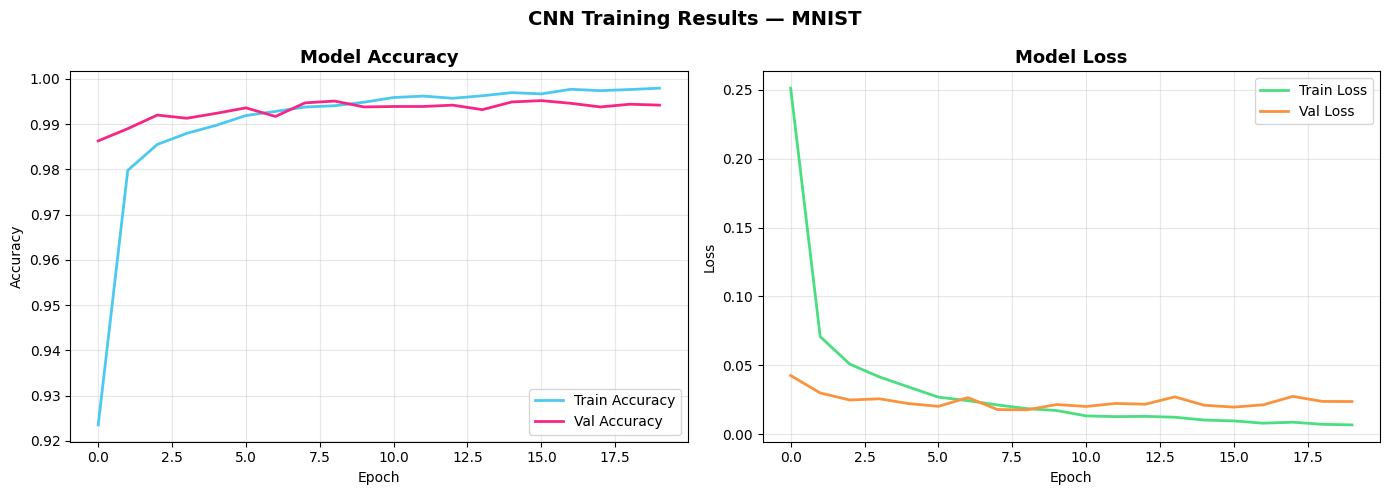

In [24]:
# ── CELL 7 — Plot Training Results ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='#4cc9f0', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#f72585', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'],     label='Train Loss', color='#4ade80', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#fb923c', linewidth=2)
axes[1].set_title('Model Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('CNN Training Results — MNIST', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# ── CELL 8 — Evaluate Model ─────────────────────────────────
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n{'='*40}")
print(f"  Test Accuracy : {test_acc * 100:.2f}%")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"{'='*40}")



  Test Accuracy : 99.42%
  Test Loss     : 0.0237


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


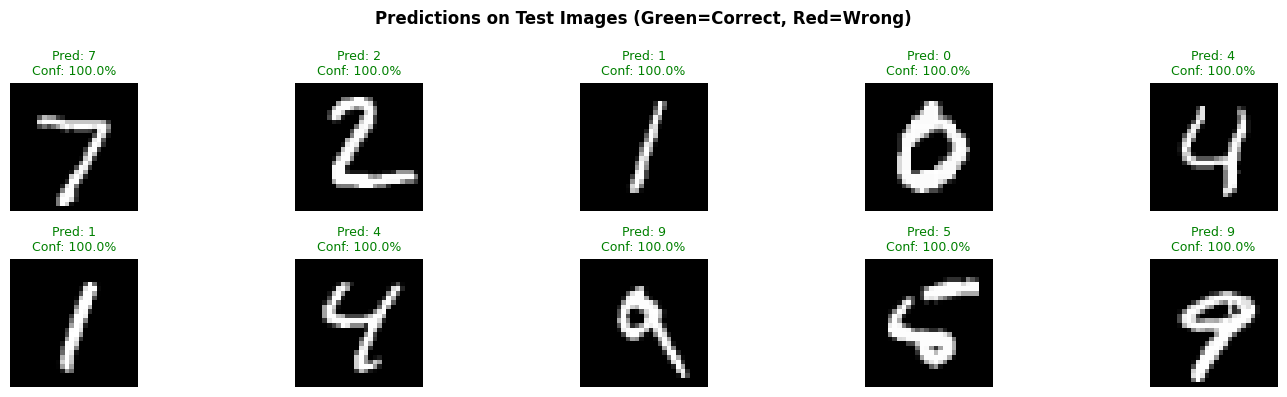

In [26]:

# ── CELL 9 — Predict on Test Samples ───────────────────────
predictions = model.predict(x_test)

# Show 10 predictions with images
plt.figure(figsize=(15, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    predicted = np.argmax(predictions[i])
    actual    = y_test[i]
    confidence = round(float(np.max(predictions[i])) * 100, 1)
    color = 'green' if predicted == actual else 'red'
    plt.title(f"Pred: {predicted}\nConf: {confidence}%", fontsize=9, color=color)
    plt.axis('off')
plt.suptitle("Predictions on Test Images (Green=Correct, Red=Wrong)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

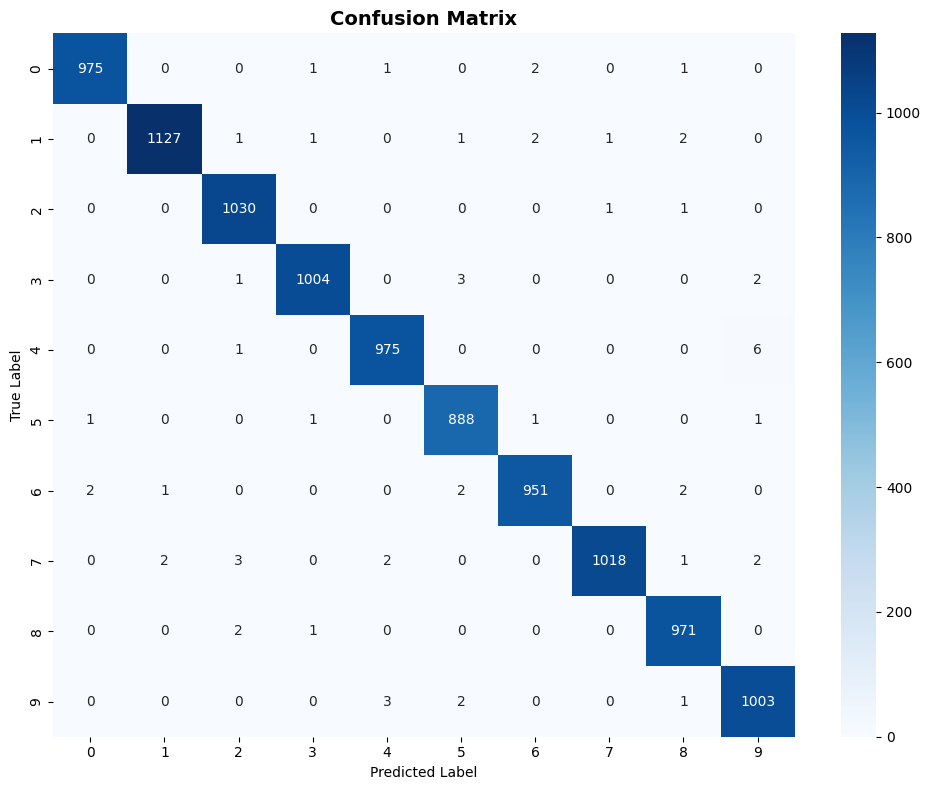


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       980
           1       1.00      0.99      1.00      1135
           2       0.99      1.00      1.00      1032
           3       1.00      0.99      1.00      1010
           4       0.99      0.99      0.99       982
           5       0.99      1.00      0.99       892
           6       0.99      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.99      1.00      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [27]:
# ── CELL 10 — Confusion Matrix ──────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = np.argmax(predictions, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))

Model saved as 'digit_recognition_model.h5' ✅

You can download this model and use it in the desktop app!


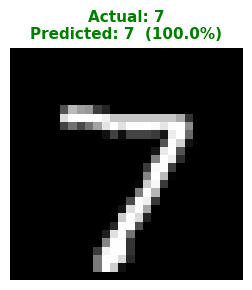

Actual Digit    : 7
Predicted Digit : 7
Confidence      : 100.0%
Result          : ✅ CORRECT


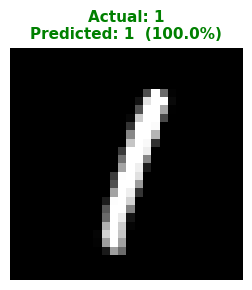

Actual Digit    : 1
Predicted Digit : 1
Confidence      : 100.0%
Result          : ✅ CORRECT


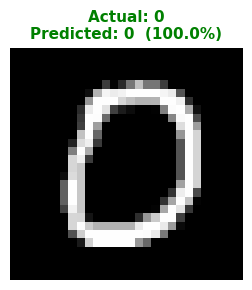

Actual Digit    : 0
Predicted Digit : 0
Confidence      : 100.0%
Result          : ✅ CORRECT


In [28]:
# ── CELL 11 — Save Model ────────────────────────────────────
model.save('digit_recognition_model.h5')
print("Model saved as 'digit_recognition_model.h5' ✅")
print("\nYou can download this model and use it in the desktop app!")

# ── CELL 12 — Test Single Prediction ───────────────────────
def predict_single(index):
    img = x_test[index]
    actual = y_test[index]
    pred = model.predict(img.reshape(1, 28, 28, 1), verbose=0)
    predicted   = np.argmax(pred)
    confidence  = round(float(np.max(pred)) * 100, 2)

    plt.figure(figsize=(3, 3))
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.title(f"Actual: {actual}\nPredicted: {predicted}  ({confidence}%)",
              fontsize=11, fontweight='bold',
              color='green' if predicted == actual else 'red')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"Actual Digit    : {actual}")
    print(f"Predicted Digit : {predicted}")
    print(f"Confidence      : {confidence}%")
    print(f"Result          : {'✅ CORRECT' if predicted == actual else '❌ WRONG'}")

# Test with index 0 — change number to test different images
predict_single(0)
predict_single(5)
predict_single(10)